In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import chi2_contingency

In [ ]:
from google.colab import drive
import os
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# for collab

def find_base(folder_name="parlamint"):
    for search_root in ["/content/drive/MyDrive", "/content/drive/Shareddrives"]:
        for root, dirs, _ in os.walk(search_root):
            if folder_name in dirs:
                return os.path.join(root, folder_name)
    raise FileNotFoundError(f"{folder_name} not found in Google Drive")

BASE = find_base()
DATA_DIR = os.path.join(BASE, "metadata_clean")

print(f"BASE: {BASE}")
print(f"METADATA: {DATA_DIR}")

BASE: /content/drive/MyDrive/parlamint
METADATA: /content/drive/MyDrive/parlamint/metadata_clean


In [ ]:
# paths
path_all = os.path.join(DATA_DIR, "master_all.tsv")
path_women = os.path.join(DATA_DIR, "master_women.tsv")

# load datasets
df_all = pd.read_csv(path_all, sep='\t')
df_women = pd.read_csv(path_women, sep='\t')

# cleaning
df_all['parliament'] = df_all['parliament'].str.strip()
df_all['Topic'] = df_all['Topic'].str.strip()
df_women['parliament'] = df_women['parliament'].str.strip()
df_women['Topic'] = df_women['Topic'].str.strip()

/tmp/ipykernel_3395/2194331489.py:6: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(path_all, sep='\t')


In [ ]:
def standardize_ideology(orientation):
    if pd.isna(orientation) or orientation == '-':
        return 'Unknown'

    # cleaning
    orientation = str(orientation).lower().strip()

    # dict with every case
    complex_mapping = {
        '-': 'Unknown',
        'big tent': 'Center',
        'centre': 'Center',
        'centre to centre-left': 'Center-Left',
        'centre to centre-right': 'Center-Right',
        'centre-left': 'Center-Left',
        'centre-left to left': 'Left',
        'centre-right': 'Center-Right',
        'centre-right to right': 'Right',
        'centre-right;centre-left': 'Center',
        'far-right': 'Far-Right',
        'left': 'Left',
        'left to far-left': 'Far-Left',
        'right': 'Right',
        'right to far-right': 'Far-Right'
    }

    if orientation in complex_mapping:
        return complex_mapping[orientation]
    else:
        return 'Unknown'

# apply function
df_all['clean_ideology'] = df_all['Party_orientation'].apply(standardize_ideology)
df_women['clean_ideology'] = df_women['Party_orientation'].apply(standardize_ideology)

In [ ]:
# topics
unique_topics = sorted([topic for topic in df_all['Topic'].dropna().unique() if topic != '-'])
print("List of Unique Topics:")
for topic in unique_topics:
    print(f"- {topic}")

# gender distribution by parliament
total_speeches = df_all.groupby('parliament').size()
female_speeches = df_women.groupby('parliament').size()

gender_distribution = (female_speeches / total_speeches) * 100
gender_distribution_df = gender_distribution.reset_index()
gender_distribution_df.columns = ['Parliament', 'Female_Representation_Percentage']

print("\n\nGender Distribution by Parliament (% of female speeches):")
print(gender_distribution_df.round(2).to_string(index=False))

List of Unique Topics:
- Agriculture
- Civil Rights
- Culture
- Defense
- Domestic Commerce
- Education
- Energy
- Environment
- Foreign Trade
- Government Operations
- Health
- Housing
- Immigration
- International Affairs
- Labor
- Law and Crime
- Macroeconomics
- Public Lands
- Social Welfare
- Technology
- Transportation


Gender Distribution by Parliament (% of female speeches):
Parliament  Female_Representation_Percentage
        EN                             32.54
        ES                             34.06
        FR                             32.28
        TR                             15.44


Saved: topic_distribution_EN.png


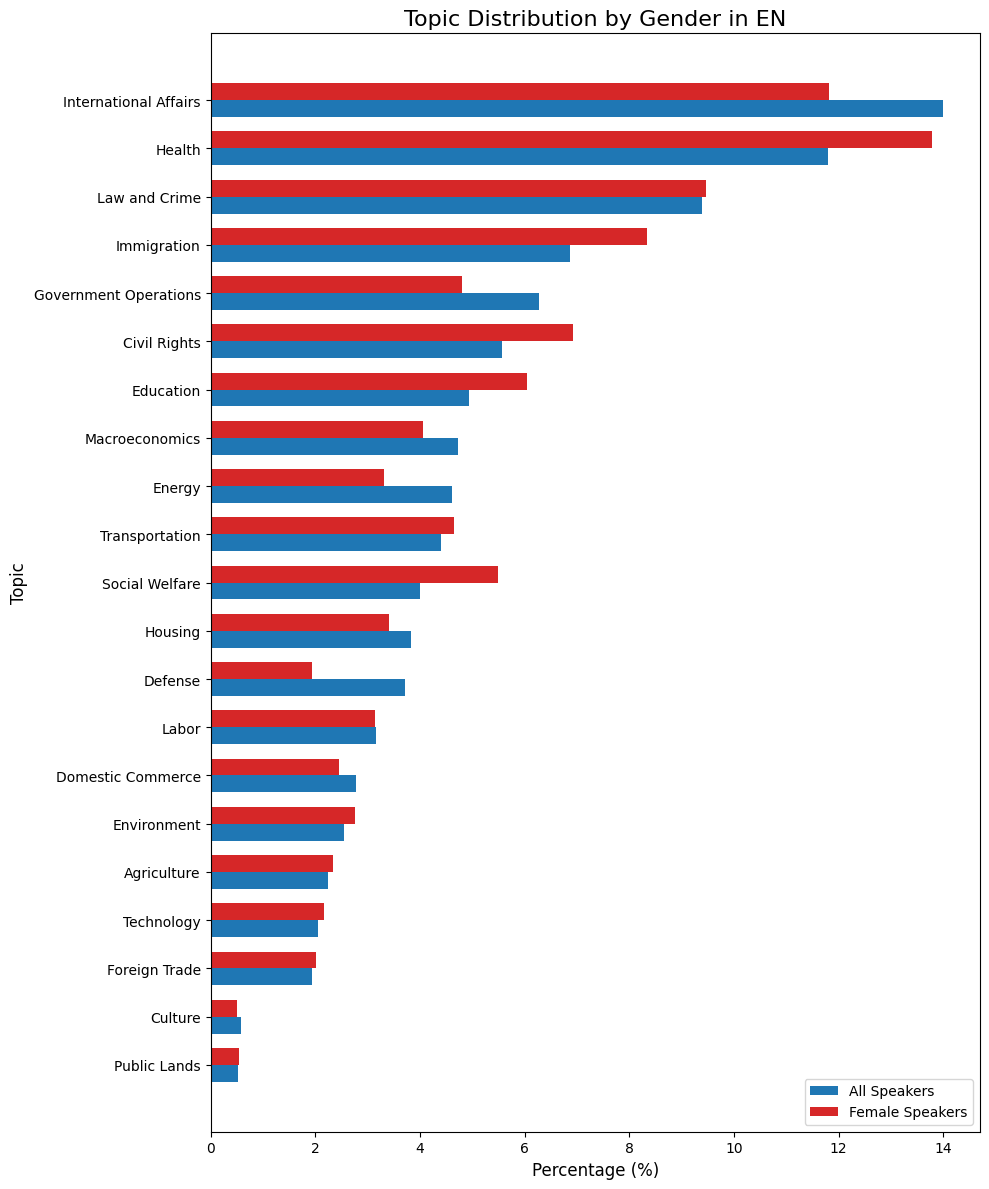

Saved: topic_distribution_ES.png


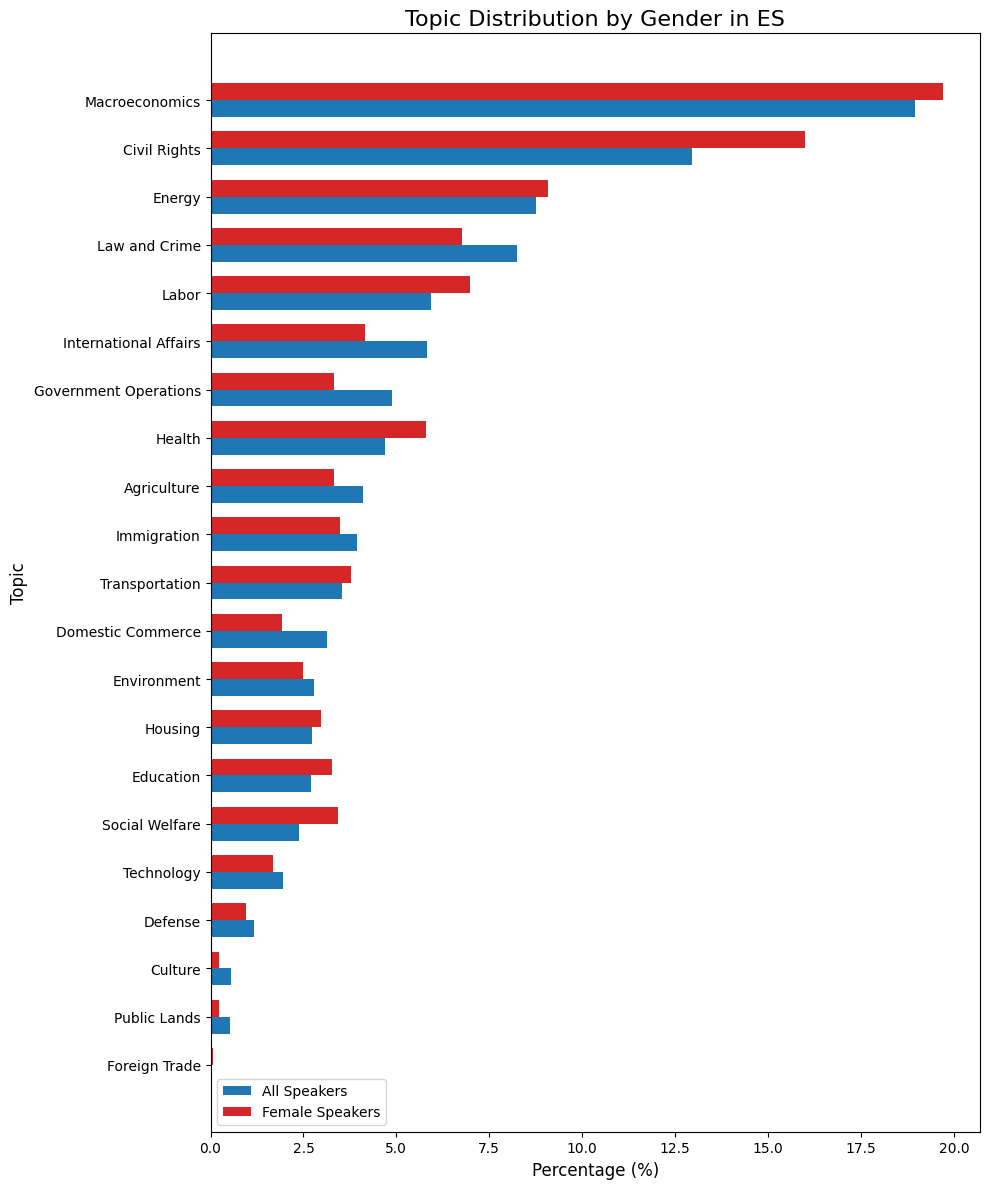

Saved: topic_distribution_FR.png


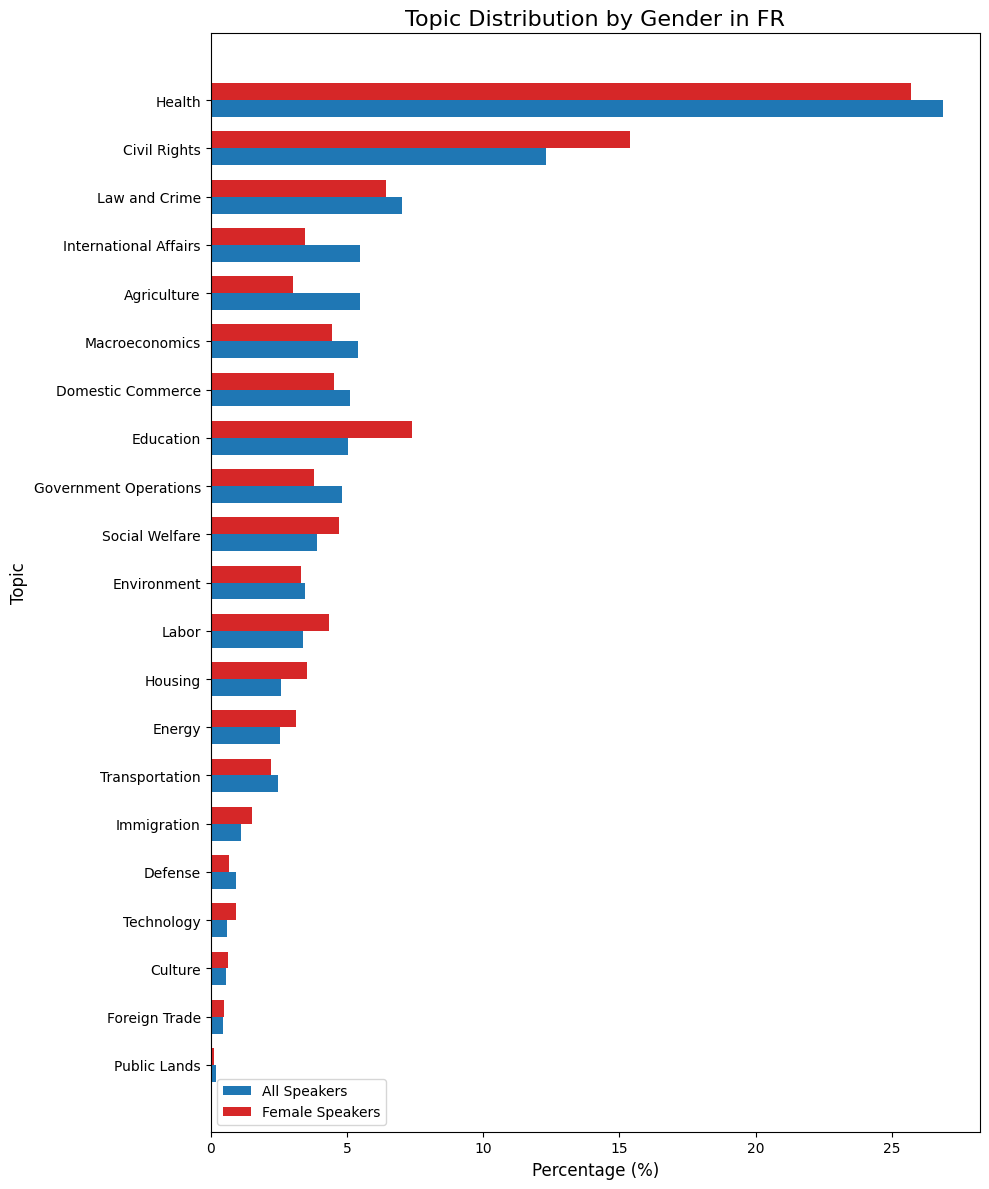

Saved: topic_distribution_TR.png


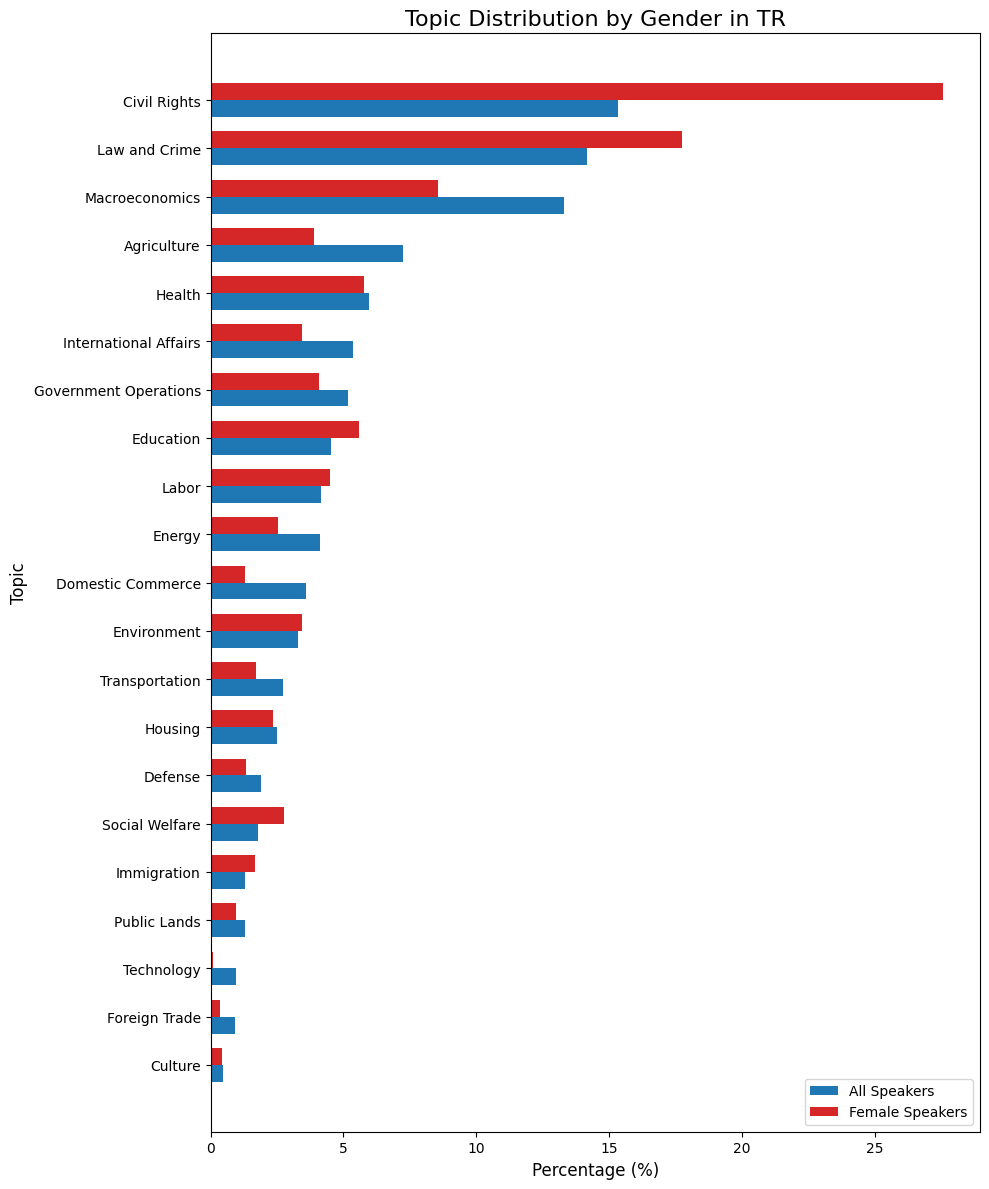

In [ ]:
parliaments = df_all['parliament'].dropna().unique()

for parliament in parliaments:
    df_all_parl = df_all[df_all['parliament'] == parliament]
    df_women_parl = df_women[df_women['parliament'] == parliament]

    topic_counts_all = df_all_parl['Topic'].value_counts()
    topic_pct_all = (topic_counts_all / topic_counts_all.sum()) * 100

    topic_counts_women = df_women_parl['Topic'].value_counts()
    topic_pct_women = (topic_counts_women / topic_counts_women.sum()) * 100

    df_combined = pd.DataFrame({
        'All Speakers': topic_pct_all,
        'Female Speakers': topic_pct_women
    }).fillna(0).sort_values(by='All Speakers', ascending=True)

    if '-' in df_combined.index:
        df_combined = df_combined.drop('-')

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 12))
    y = np.arange(len(df_combined))
    height = 0.35

    ax.barh(y - height/2, df_combined['All Speakers'], height, label='All Speakers', color='#1f77b4')
    ax.barh(y + height/2, df_combined['Female Speakers'], height, label='Female Speakers', color='#d62728')

    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_ylabel('Topic', fontsize=12)
    ax.set_title(f'Topic Distribution by Gender in {parliament}', fontsize=16)
    ax.set_yticks(y)
    ax.set_yticklabels(df_combined.index)
    ax.legend()

    plt.tight_layout()

    # save
    filename_bar = f'topic_distribution_{parliament}.png'
    plt.savefig(filename_bar, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename_bar}")

    plt.show()

In [ ]:
print("=== STATISTICAL ANALYSIS: GENDER VS TOPIC BY PARLIAMENT ===\n")

# Iterate through each parliament
for parliament in sorted(df_all["parliament"].unique()):

    # Filter by parliament and retain only Male and Female speakers
    subset = df_all[
        (df_all["parliament"] == parliament) &
        (df_all["Speaker_gender"].isin(["F", "M"]))
    ]

    # 1. Contingency Table: Observed Frequencies (O)
    table = pd.crosstab(
        subset["Speaker_gender"],
        subset["Topic"]
    )

    # 2. Chi-square test and Expected Frequencies (E)
    chi2, p, dof, expected = chi2_contingency(table)

    # 3. Cramér's V (Effect Size)
    # Formula: sqrt(chi2 / (N * min(r-1, k-1)))
    n = table.sum().sum()
    r, k = table.shape
    cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))

    print(f"[{parliament} PARLIAMENT]")
    print(f"  Chi-square = {chi2:.2f} | p-value = {p:.6g} | Cramer's V = {cramers_v:.3f}")

    # Proceed with Standardized Residuals only if the association is significant
    if p < 0.05:
        # 4. Standardized Residuals (Z)
        # Formula: (O - E) / sqrt(E)
        residuals = (table - expected) / np.sqrt(expected)

        # Focus on Female speakers ("F") to test H1 and H2
        if "F" in residuals.index:
            residuals_f = residuals.loc["F"]

            # Z > 1.96 indicates significant overrepresentation
            overrepresented = residuals_f[residuals_f > 1.96].sort_values(ascending=False)

            # Z < -1.96 indicates significant underrepresentation
            underrepresented = residuals_f[residuals_f < -1.96].sort_values(ascending=True)

            print("  -> Overrepresented topics by women (Testing H2):")
            if not overrepresented.empty:
                for topic, z_score in overrepresented.items():
                    print(f"     - {topic} (Z = {z_score:.2f})")
            else:
                print("     None significant.")

            print("  -> Underrepresented topics by women (Testing H1):")
            if not underrepresented.empty:
                for topic, z_score in underrepresented.items():
                    print(f"     - {topic} (Z = {z_score:.2f})")
            else:
                print("     None significant.")
    else:
         print("  No significant association between gender and topic.")

=== STATISTICAL ANALYSIS: GENDER VS TOPIC BY PARLIAMENT ===

[EN PARLIAMENT]
  Chi-square = 873.75 | p-value = 3.0268e-172 | Cramer's V = 0.138
  -> Overrepresented topics by women (Testing H2):
     - Social Welfare (Z = 9.17)
     - Civil Rights (Z = 7.06)
     - Health (Z = 7.06)
     - Immigration (Z = 6.81)
     - Education (Z = 6.11)
  -> Underrepresented topics by women (Testing H1):
     - Defense (Z = -11.29)
     - Energy (Z = -7.45)
     - Government Operations (Z = -7.23)
     - International Affairs (Z = -7.17)
     - Macroeconomics (Z = -3.75)
     - Housing (Z = -2.62)
     - Domestic Commerce (Z = -2.35)
[ES PARLIAMENT]
  Chi-square = 129.97 | p-value = 1.02662e-17 | Cramer's V = 0.173
  -> Overrepresented topics by women (Testing H2):
     - Civil Rights (Z = 3.53)
     - Social Welfare (Z = 2.90)
     - Health (Z = 2.14)
  -> Underrepresented topics by women (Testing H1):
     - Government Operations (Z = -2.98)
     - International Affairs (Z = -2.90)
     - Domestic

Saved: gender_gap_heatmap_EN.png


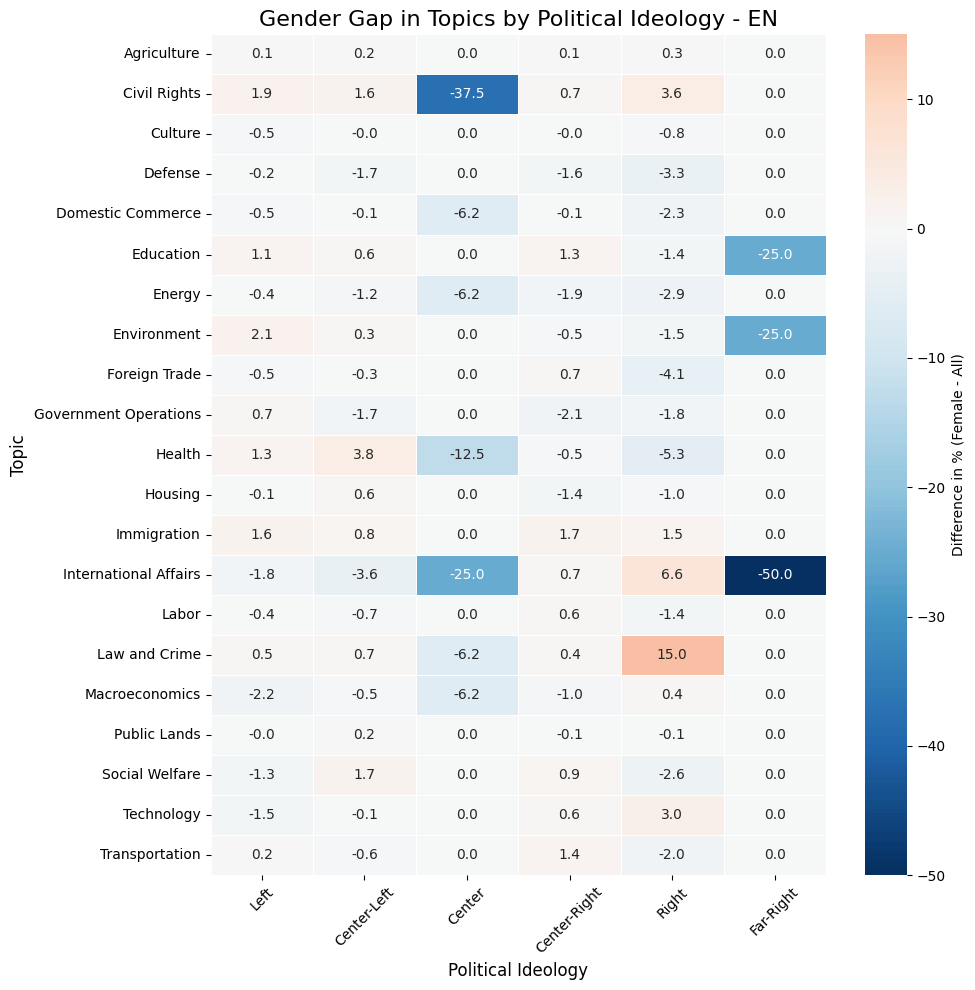

Saved: gender_gap_heatmap_ES.png


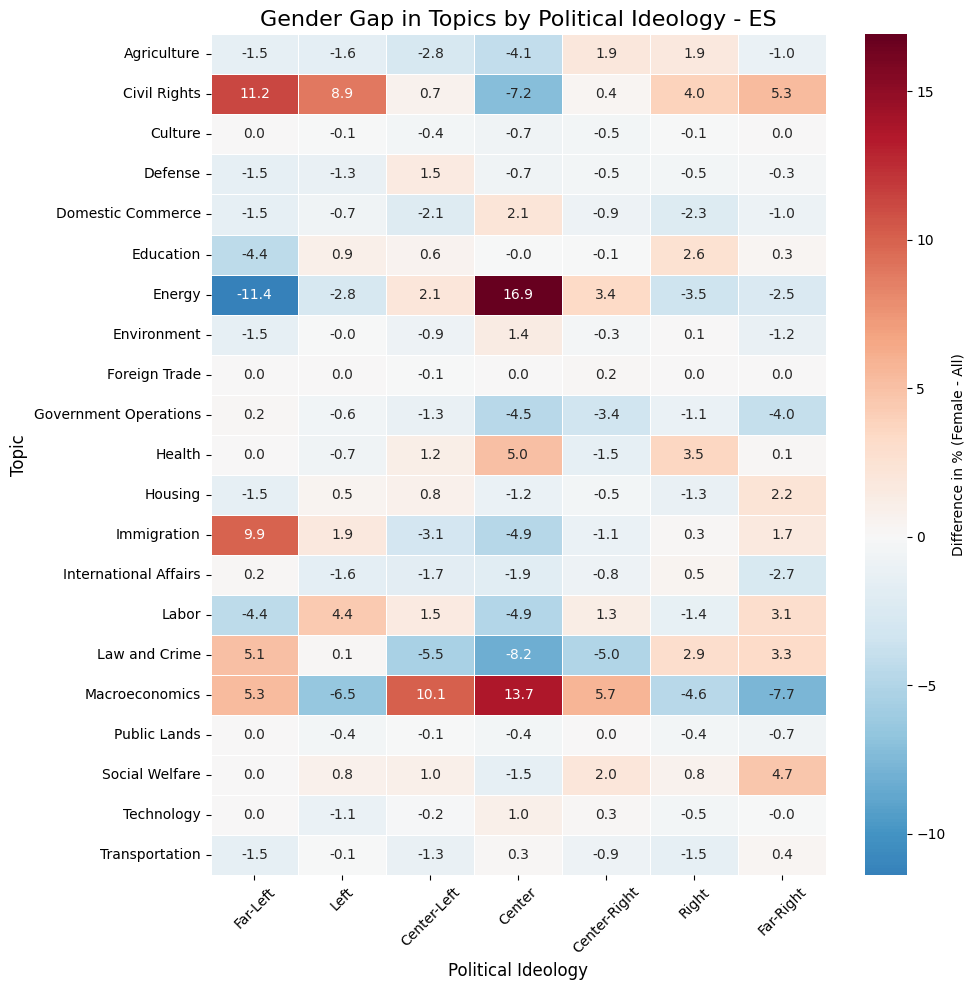

Saved: gender_gap_heatmap_FR.png


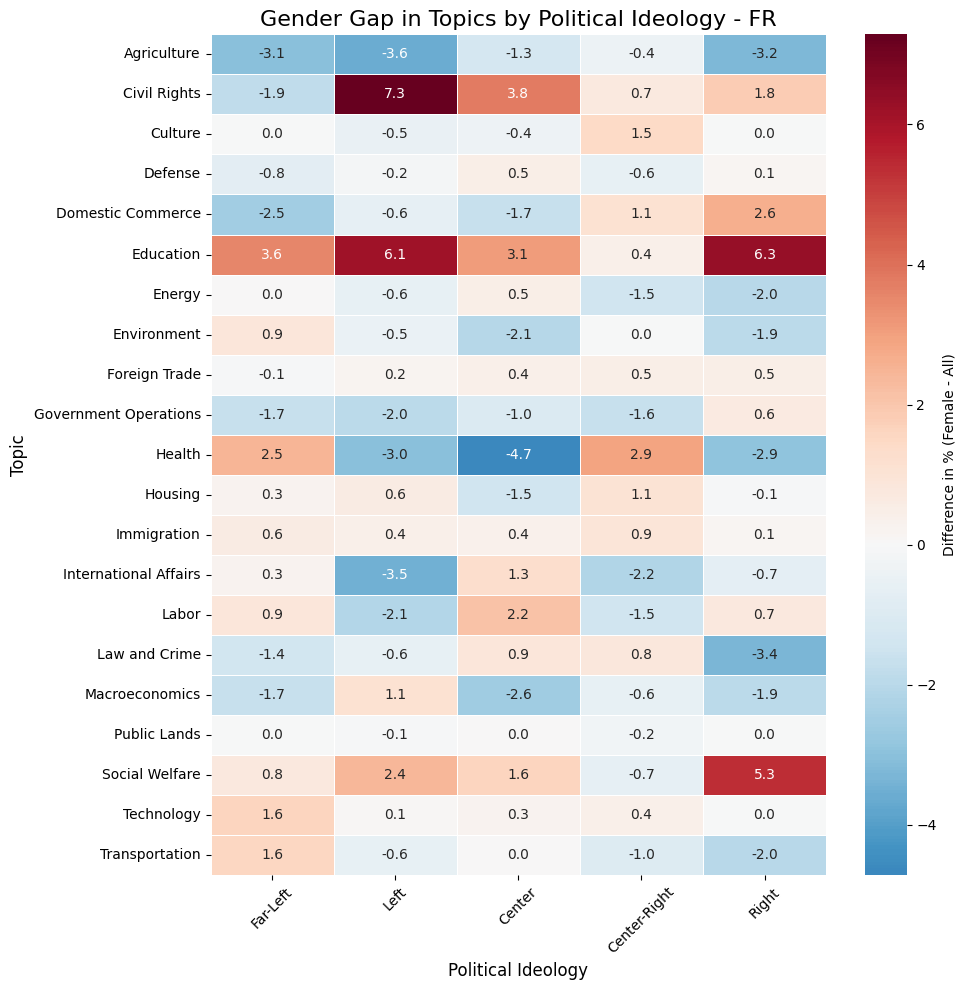

Saved: gender_gap_heatmap_TR.png


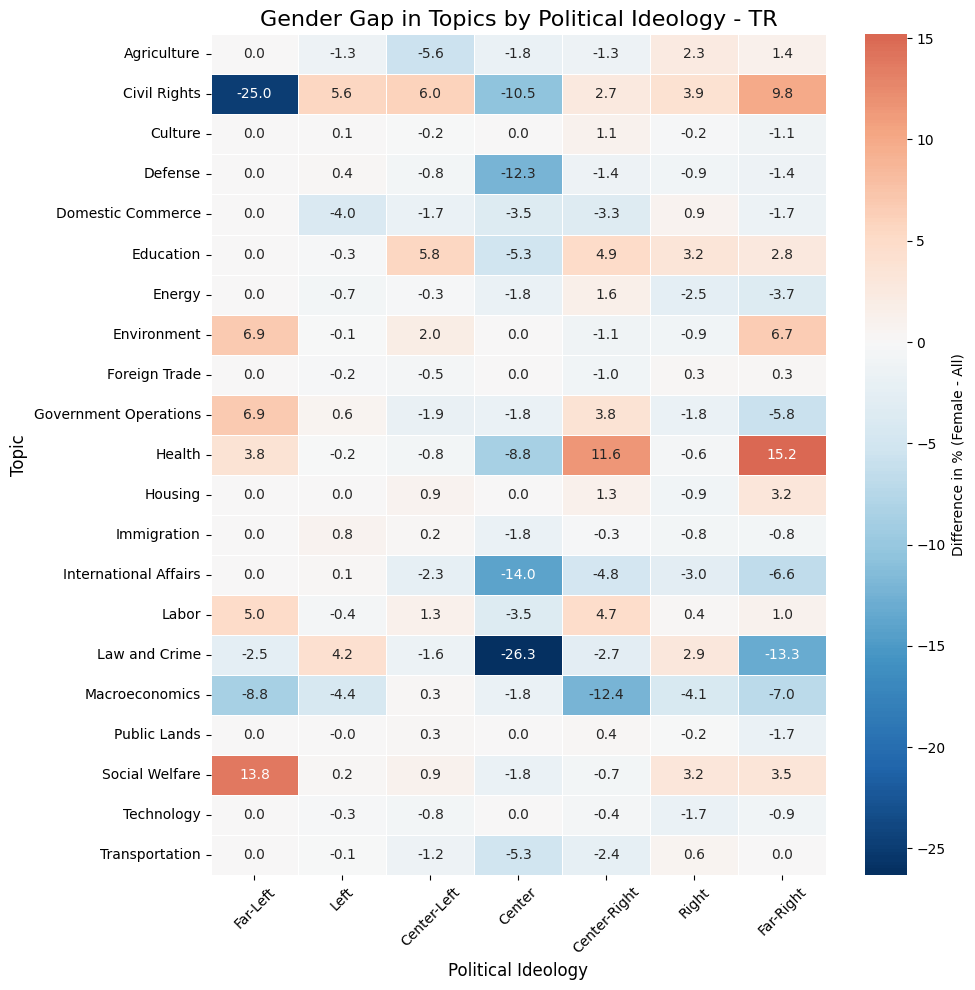

In [ ]:
# Desired order for the X-axis (Ideology)
ideology_order = ['Far-Left', 'Left', 'Center-Left', 'Center', 'Center-Right', 'Right', 'Far-Right', 'Other']

for parliament in parliaments:
    df_all_p = df_all[df_all['parliament'] == parliament]
    df_women_p = df_women[df_women['parliament'] == parliament]

    counts_all_ideo = df_all_p.groupby(['clean_ideology', 'Topic']).size().unstack(fill_value=0)
    pct_all_ideo = counts_all_ideo.div(counts_all_ideo.sum(axis=1), axis=0) * 100

    counts_women_ideo = df_women_p.groupby(['clean_ideology', 'Topic']).size().unstack(fill_value=0)
    pct_women_ideo = counts_women_ideo.div(counts_women_ideo.sum(axis=1), axis=0) * 100

    pct_all_ideo, pct_women_ideo = pct_all_ideo.align(pct_women_ideo, fill_value=0)
    delta_ideo = pct_women_ideo - pct_all_ideo

    heatmap_data = delta_ideo.T

    if '-' in heatmap_data.index:
        heatmap_data = heatmap_data.drop('-')

    available_ideologies = [i for i in ideology_order if i in heatmap_data.columns]
    heatmap_data = heatmap_data[available_ideologies]

    # Plot Heatmap
    plt.figure(figsize=(10, 10))
    sns.heatmap(heatmap_data,
                cmap='RdBu_r',
                center=0,
                annot=True,
                fmt=".1f",
                linewidths=.5,
                cbar_kws={'label': 'Difference in % (Female - All)'})

    plt.title(f'Gender Gap in Topics by Political Ideology - {parliament}', fontsize=16)
    plt.xlabel('Political Ideology', fontsize=12)
    plt.ylabel('Topic', fontsize=12)
    plt.xticks(rotation=45)

    plt.tight_layout()

    # save
    filename_heat = f'gender_gap_heatmap_{parliament}.png'
    plt.savefig(filename_heat, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename_heat}")

    plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

print("=== STATISTICAL ANALYSIS: IDEOLOGY VS TOPIC (FEMALE SPEAKERS) ===\n")

df_women_only = df_all[(df_all["Speaker_gender"] == "F") & (df_all["clean_ideology"] != "Unknown")]

for parliament in sorted(df_women_only["parliament"].unique()):
    print(f"[{parliament} PARLIAMENT - FEMALE SPEAKERS]")

    subset = df_women_only[df_women_only["parliament"] == parliament]

    table = pd.crosstab(
        subset["clean_ideology"],
        subset["Topic"]
    )

    if table.empty or table.shape[0] < 2:
        print("  Not enough ideological groups for comparison.\n")
        print("-" * 65)
        continue

    # Chi-squared
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramer's V
    n = table.sum().sum()
    r, k = table.shape
    cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))

    print(f"  Chi-square = {chi2:.2f} | p-value = {p:.6g} | Cramer's V = {cramers_v:.3f}")

    if p < 0.05:
        residuals = (table - expected) / np.sqrt(expected)

        for ideology in residuals.index:
            res_ideology = residuals.loc[ideology]
            over = res_ideology[res_ideology > 1.96].sort_values(ascending=False)
            under = res_ideology[res_ideology < -1.96].sort_values(ascending=True)

            if not over.empty or not under.empty:
                print(f"  -> Ideology: {ideology}")
                if not over.empty:
                    over_str = ", ".join([f"{k} (Z={v:.2f})" for k, v in over.items()])
                    print(f"       OVERrepresented: {over_str}")
                if not under.empty:
                    under_str = ", ".join([f"{k} (Z={v:.2f})" for k, v in under.items()])
                    print(f"       UNDERrepresented: {under_str}")
    else:
        print("  No significant association between ideology and topic for women in this parliament.")


=== STATISTICAL ANALYSIS: IDEOLOGY VS TOPIC (FEMALE SPEAKERS) ===

[EN PARLIAMENT - FEMALE SPEAKERS]
  Chi-square = 1014.62 | p-value = 1.62194e-173 | Cramer's V = 0.154
  -> Ideology: Center-Left
       OVERrepresented: Government Operations (Z=5.67), Health (Z=5.30), Social Welfare (Z=5.20), Housing (Z=4.29), Civil Rights (Z=4.20), Macroeconomics (Z=3.67)
       UNDERrepresented: International Affairs (Z=-7.39), Transportation (Z=-6.97), Technology (Z=-4.04), Defense (Z=-3.98), Foreign Trade (Z=-3.80)
  -> Ideology: Center-Right
       OVERrepresented: International Affairs (Z=7.74), Transportation (Z=7.31), Technology (Z=4.68), Defense (Z=4.58), Foreign Trade (Z=4.34), Labor (Z=2.75)
       UNDERrepresented: Government Operations (Z=-6.09), Civil Rights (Z=-4.70), Health (Z=-4.47), Social Welfare (Z=-4.17), Housing (Z=-3.95), Macroeconomics (Z=-3.23), Environment (Z=-3.22), Immigration (Z=-2.42)
  -> Ideology: Left
       OVERrepresented: Environment (Z=12.54), Energy (Z=8.60), Agri

In [ ]:
# download figs

'''from google.colab import files
import glob

saved_plots = glob.glob('*.png')

for plot in saved_plots:
    files.download(plot)'''

"from google.colab import files\nimport glob\n\nsaved_plots = glob.glob('*.png')\n\nfor plot in saved_plots:\n    files.download(plot)"